# Day 4.4 — Parallel Specialist Reviewers
Three narrow reviewers read the same file and answer different questions about it. Say the words
precisely — fan-out, shared state, handoff, fan-in — because each is a place these systems break.

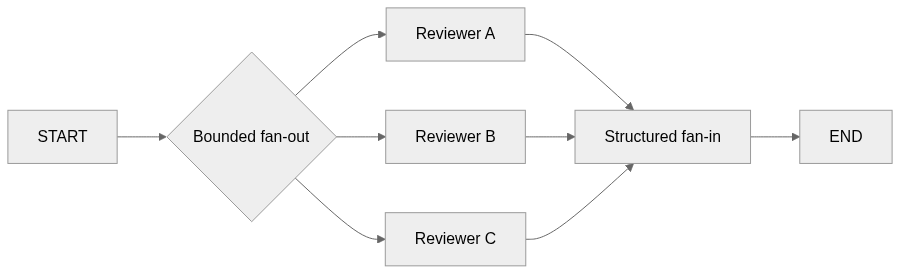

*D13 — one bounded fan-out into three reviewers, then a structured fan-in*

### Step 1 — The vocabulary, on this exact example

- **Shared state** — what every branch reads: `SOURCE`, one immutable string. Nothing writes to
  it, which is why the branches are safe to run at the same time.
- **Fan-out** — one step launches independent branches. Ours is bounded: three roles, three calls,
  and no branch may spawn another.
- **Handoff** — what crosses the boundary between agents. Only `Finding` records: no personas, no
  chat history, no hidden reasoning.
- **Fan-in** — one step collects every branch's output and combines it: the supervisor, in 4.5.

Narrowing a prompt redistributes attention; it does not create capability. If the generalist
cannot see a business rule, a narrower specialist usually cannot either.

In [ ]:
SPECIALIST_ROLES = ("correctness", "security", "maintainability")

print("Bounded fan-out width:", len(SPECIALIST_ROLES), "| roles:", list(SPECIALIST_ROLES))
print("Shared state         : one immutable string of", len(SOURCE), "characters")
print("Does any branch write to it? no - each returns its own list of findings\n")

for role in SPECIALIST_ROLES:
    role_findings, _usage = call_reviewer(SOURCE, role, reviewer_blind)
    print(f"{role:<16} -> {len(role_findings)} finding(s): "
          + ", ".join(f"line {f.line}" for f in role_findings))
    assert all(f.category == role for f in role_findings)     # enforced by parse_findings
print("\nEvery finding stayed inside its reviewer's category - the role contract held.")

### Step 2 — Look at one handoff record

The entire message the security specialist sends onward. Compare it with "here is my
conversation, please read it": small, validated, mergeable.

In [ ]:
handoff, _usage = call_reviewer(SOURCE, "security", reviewer_blind)
for name, value in handoff[0].model_dump().items():
    print(f"{name:>15}: {value}")
print("\nWhat is NOT in the handoff: the prompt, the reasoning, the chat history.")

### Step 3 — Sequential first, because it is easy to debug

`fan_out` runs the three branches: call one, wait, call the next. The mock gets a 0.3 s delay so
it behaves like a network call.

In [ ]:
from concurrent.futures import ThreadPoolExecutor

def fan_out(source, model, parallel=True):
    """Run every specialist over the same immutable source. Returns [(role, findings, usage)]."""
    def branch(role):
        role_findings, usage = call_reviewer(source, role, model)    # each branch: 1 model call
        return role, role_findings, usage
    if parallel:
        # Bounded at exactly three workers: three roles, three calls, no branch spawns another.
        with ThreadPoolExecutor(max_workers=len(SPECIALIST_ROLES)) as pool:
            return list(pool.map(branch, SPECIALIST_ROLES))
    return [branch(role) for role in SPECIALIST_ROLES]

slow_reviewer = make_mock_model("blind_spots", latency_s=0.3)        # pretend network latency

start = perf_counter()
sequential = fan_out(SOURCE, slow_reviewer, parallel=False)
sequential_seconds = perf_counter() - start

print("Execution  : sequential")
print("Branches   :", [role for role, _f, _u in sequential])
print("Model calls:", len(sequential), "| tokens:", sum(u["total_tokens"] for _r, _f, u in sequential))
print("Wall clock : %.2f s" % sequential_seconds)

### Step 4 — Now fan out into threads

`ThreadPoolExecutor` starts the three calls together: while one branch waits on the network the
others wait too, so the total is roughly the *longest* call, not the sum.

In [ ]:
start = perf_counter()
parallel = fan_out(SOURCE, slow_reviewer, parallel=True)
parallel_seconds = perf_counter() - start

print(f"{'measure':<22}{'sequential':>12}{'parallel':>12}")
print("-" * 46)
print(f"{'wall clock (s)':<22}{sequential_seconds:>12.2f}{parallel_seconds:>12.2f}")
print(f"{'model calls':<22}{len(sequential):>12}{len(parallel):>12}")
print(f"{'tokens':<22}{sum(u['total_tokens'] for _r, _f, u in sequential):>12}"
      f"{sum(u['total_tokens'] for _r, _f, u in parallel):>12}")
print(f"{'findings':<22}{sum(len(f) for _r, f, _u in sequential):>12}"
      f"{sum(len(f) for _r, f, _u in parallel):>12}")
print("\nSpeed-up: %.1fx" % (sequential_seconds / parallel_seconds))
print("Parallel execution buys wall-clock time. It does not reduce calls, tokens or cost,")
print("and it reaches a provider's rate limit three times faster.")

### Try it yourself

The pool is capped at three workers. Predict the wall clock at **one** worker instead.

In [ ]:
# --- Worked solution ---------------------------------------------------------------
# Fan out by hand so the bound is visible: max_workers is the whole cap.
def timed_fan_out(max_workers):
    start = perf_counter()
    with ThreadPoolExecutor(max_workers=max_workers) as pool:
        results = list(pool.map(lambda role: call_reviewer(SOURCE, role, slow_reviewer), SPECIALIST_ROLES))
    return perf_counter() - start, sum(len(f) for f, _u in results)

for workers in (1, 2, 3):
    seconds, total = timed_fan_out(workers)
    print("max_workers=%d -> %.2f s, %d findings, 3 model calls" % (workers, seconds, total))
print("\nmax_workers=1 is sequential execution wearing a thread pool.")
print("The findings and the bill never change; only how long we wait does.")

### Checkpoint

**1. Why is it safe to run these three reviewers at the same time?**

<details><summary>Show answer</summary>

The shared state is read-only: each branch reads the same immutable `SOURCE` and writes only to its own list, so no order of execution can make them interfere. A branch that *modified* shared state would need locking or a merge rule.

</details>

**2. Your manager says "run the specialists in parallel to cut our API bill". What do you reply?**

<details><summary>Show answer</summary>

Parallelism does not touch the bill: both runs made the same 3 calls with the same tokens; only the wall clock fell. To cut cost you must remove calls.

</details>

### Recap

- **Limitation seen:** running three specialists one after another costs the sum of all three waits.
- **Layer added:** a bounded fan-out over read-only state, with `Finding` records as the only handoff.
- **Evidence:** roughly 0.9 s → 0.3 s wall clock with identical findings, calls and tokens.